# Pandas

***Multivariate*** data are common in sciences. A meteorological example is a weather station that records temperature, humidity, wind speed, wind direction, precipitation, solar radiation, and measurement time. Tools that recognize the relationships between variables make analysis easier.

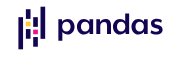

[Pandas](https://pandas.pydata.org/) is the dominant Python package for ***tabular*** (table) data. (Xarray will be used for multi-dimensional data.)  

### Pandas features

* Fast, efficient manipulation and indexing of tabular data
* Tools for reading and writing spreadsheet and database files: Excel, comma separated values (csv), text files, SQL, etc...
* Convenient time representation

### Pandas vs. spreadsheets

Spreadsheet programs (e.g. Excel) also work with tabular data. Spreadsheets are good for viewing data values and basic plotting, but have limited data analysis capabilities. Pandas enables larger and more complex analyses than spreadsheets.


In [ ]:
# Import pandas
import pandas as pd
# pd is the conventional alias for pandas

import numpy as np

# Temporary
try:
    import openpyxl
except ModuleNotFoundError:
    %conda install openpyxl

## Pandas data representation: `DataFrame` and `Series`

A `DataFrame` is the main datatype in pandas.

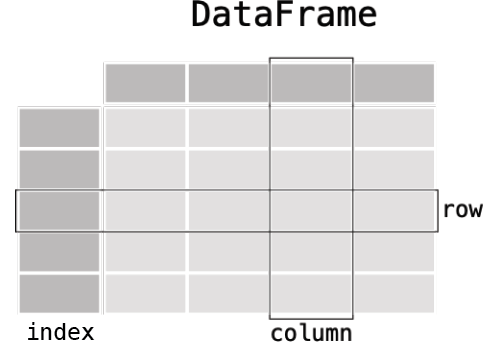

Within a column, all have the same data type (integer, float, string, boolean), but data types can vary between columns.


In [ ]:
# Manually create a DataFrame with Titanic passenger info (name, age, sex)
df = pd.DataFrame(
    # Converted from a dictionary of lists
    {
        "Name": [
            "Braund, Mr. Owen Harris",
            "Allen, Mr. William Henry",
            "Bonnell, Miss. Elizabeth",
        ],
        "Age": [22, 35, 58],
        "Sex": ["male", "male", "female"],
    }
)

In [ ]:
# Display DataFrame like a spreadsheet
df

Spreadsheet programs display information similarly.

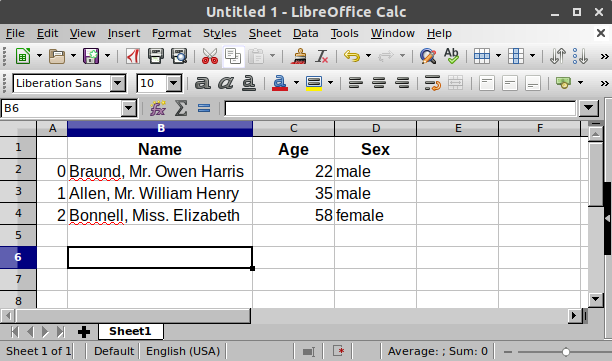

In [ ]:
# Column labels
df.columns

In [ ]:
# Index values
df.index

#### Each column in a `DataFrame` is a `Series`

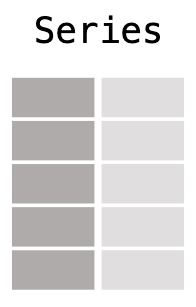

In [ ]:
# Access a single column of a DataFrame, just like keys in a dictionary
df['Age']

## Read and write tabular files

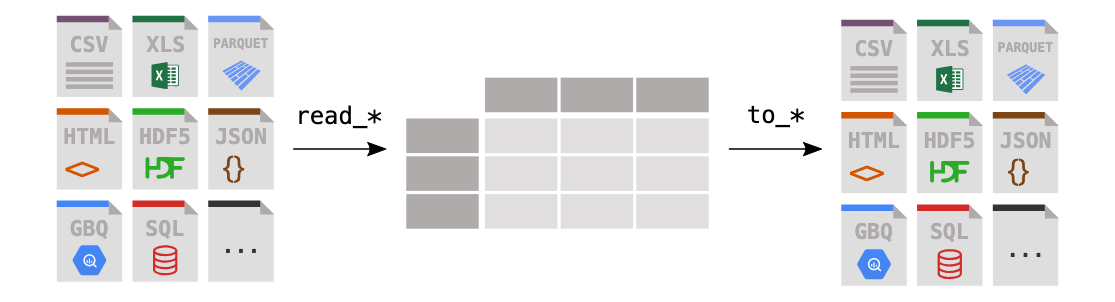


We will read a comma separated value (CSV) file containing many passengers of the Titanic.

In [ ]:
# Read comma separated values (csv)
titanic = pd.read_csv('datasets/titanic.csv')

In [ ]:
# Show the first 5 rows
titanic.head()

# Show the first 3 rows
# titanic.head(3)

In [ ]:
# Last 5 rows
titanic.tail()

# Last 3 rows
# titanic.tail(3)

In [ ]:
# Technical summary of DataFrame: size, columns, data types, memory
titanic.info()

In [ ]:
# Basic statistical summary of numerical columns
titanic.describe()

In [ ]:
# Shape of the data (rows, columns)
titanic.shape

In [ ]:
# Save the DataFram as an excel file
titanic.to_excel("titanic.xlsx", sheet_name="passengers", index=False)

In [ ]:
# Read an Excel file
titanic = pd.read_excel("titanic.xlsx", sheet_name="passengers")

#### Exercise

The file 'datasets/air_quality_no2.csv' contains measurements of the air pollutant NO<sub>2</sub> in 3 cities. Read this file using `pd.read_csv()`.

Follow these typical steps for reading a CSV or text-based data file.

0. Open the file with a text editor to see the original data. Inspect the following.
    - Number and Names of columns/variables
    - Values expected in first few rows
    - How are missing data represented?
1. Start with `pd.read_csv('datasets/air_quality_no2.csv')`
2. Inspect the result with `head()`, `info()`, and `describe()` to check if results look reasonable.
3. Consult [`read_csv` documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) and add the `parse_dates=` keyword to your `read_csv()` command.

<details>
<summary>Click to show file</summary>

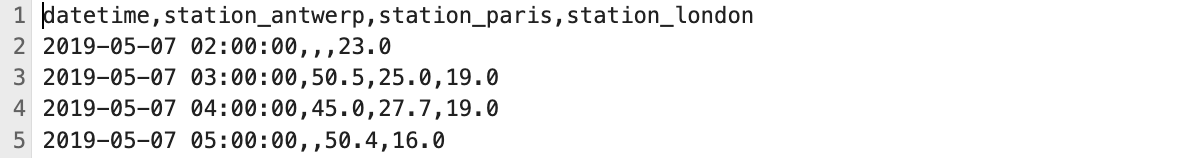
</details>

In [ ]:
filename = 'datasets/air_quality_no2.csv'

# Write your code here


#### Exercise

The first attempt to read CSV and other data files often produces unexpected results that need to be fixed.  We will explore how to deal with some of the most common issues.

The file 'datasets/enso_sst.csv' contains measurements of sea-surface temperature (SST) in several regions of the Pacific Ocean (called NINO1+2, NINO3, NINO3.4, and NINO4).

0. Open the file with a text editor to see the original data. Inspect the following.
    - Number and Names of columns/variables
    - Values expected in first few rows
    - How are missing data represented?
    - Does the file have any comments and how are they marked?
1. Start with `pd.read_csv('datasets/enso_sst.csv')`
2. Inspect the result with `head()`, `info()`, and `describe()` to check if results look reasonable.
3. Consult [`read_csv` documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) and add the `comment=` keyword to your `read_csv()` command.

<details>
<summary>Click to show file</summary>

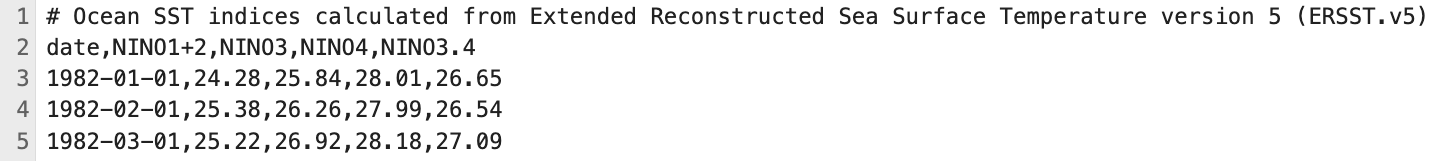
</details>

In [ ]:
filename = 'datasets/enso_sst.csv'

# Write your code here

#### Exercise

Next, we will work through reading a file with a few more common challenges.  

The file 'datasets/NOAA-CRN-Millbrook-2017.txt' contains daily weather measurements at the NOAA Climate Reference Network (CRN) site in Millbrook, NY.

0. Open the file with a text editor to see the original data. Inspect the following.
    - Notice that variables are separated by white space ' ' rather than commas ','
    - Number and Names of columns/variables
    - Values expected in first few rows
    - How are missing data represented?
    - Does the file have any comments and how are they marked?
1. Start with `pd.read_csv('datasets/NOAA-CRN-Millbrook-2017.txt')`
2. Inspect the result with `head()`, `info()`, and `describe()` to check if results look reasonable.
3. Consult [`read_csv` documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) and make corrections. Use the `sep=`, `na_values=`, `parse_dates=` keywords.
4. Repeat steps 2 and 3.

<details>
<summary>Click to show file</summary>

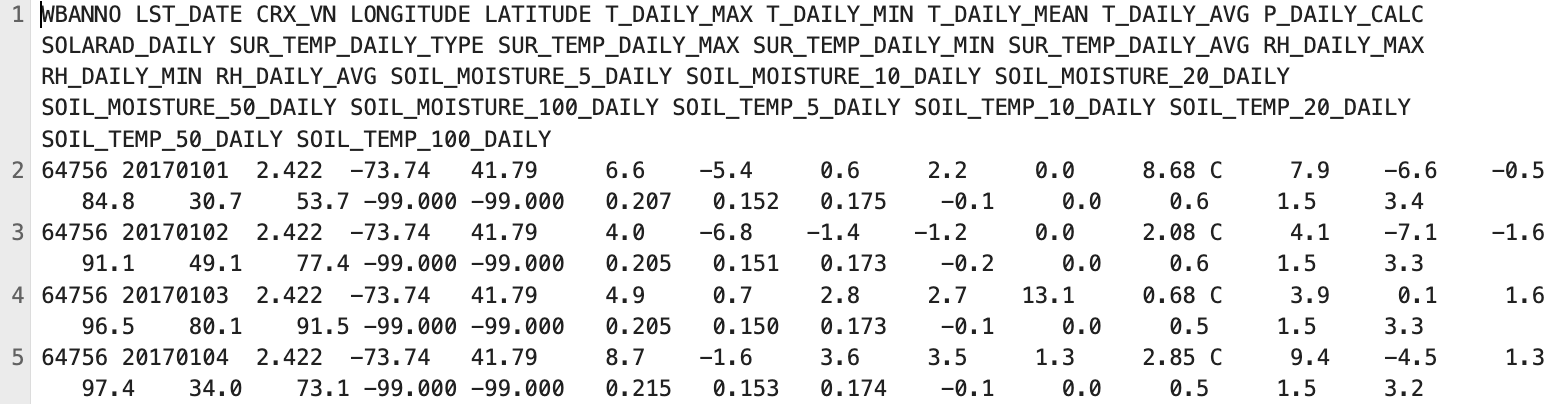
</details>

<details>

```
df = pd.read_csv(filename)
    
df = pd.read_csv(filename, sep=r'\s+')

df = pd.read_csv(datafile, sep=r'\s+', 
            na_values=[-9999.0, -99.0])

df = pd.read_csv(datafile, sep=r'\s+', 
            na_values=[-9999.0, -99.0], 
            parse_dates=['LST_DATE'])
```

    
</details>

In [ ]:
filename = 'datasets/NOAA-CRN-Millbrook-2017.txt'

# Write your code here

REMEMBER
* Getting data in to pandas from many different file formats or data sources is supported by `read_*` functions.
* Exporting data out of pandas is provided by different `to_*` methods.
* The `head`/`tail`/`info` methods and the `dtypes` attribute are convenient for a first check.

## Select columns from a `DataFrame`

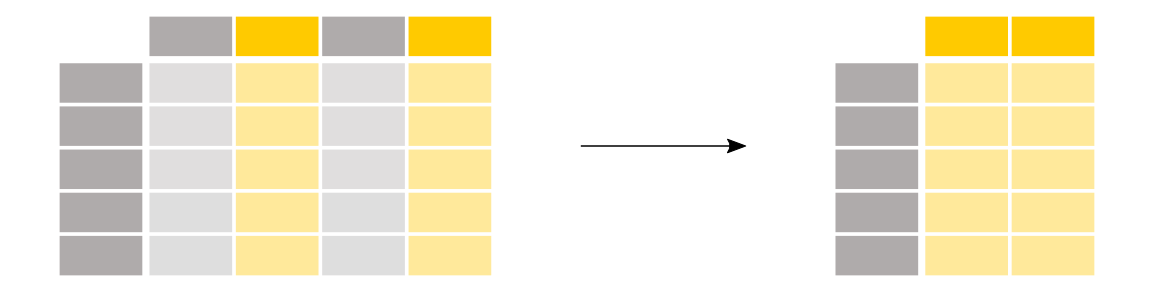

In [ ]:
# Select a single column with []
ages = titanic["Age"]

In [ ]:
# A single column is a Series
type(ages)

In [ ]:
# A single column has the shape of a 1D array
ages.shape

In [ ]:
# select two or more columns with a list of column names
age_sex = titanic[["Age", "Sex"]]

In [ ]:
# Two or more columns are a DataFrame
type(age_sex)

In [ ]:
# Two or more columns have the shape of a 2D array
age_sex.shape

## Select rows from a DataFrame

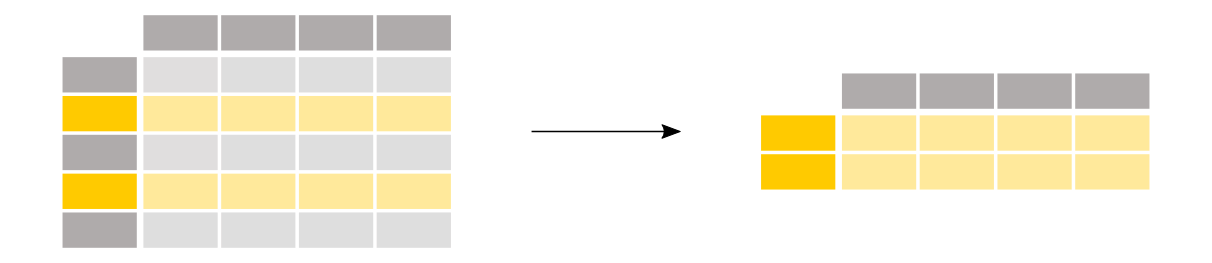


In [ ]:
# Select a single row by index value
titanic.loc[2]

In [ ]:
# Select a slice 
titanic.loc[2:5]

In [ ]:
# Select a rows by index location, which is the same as the index value in this example
titanic.iloc[2]

In [ ]:
# Select rows using a boolean array
titanic.loc[ titanic['Age'] > 35 ]

In [ ]:
# Select rows using a boolean array: two criteria
titanic.loc[ (titanic['Age'] > 35) & (titanic['Sex']=='female') ]

In [ ]:
# Some boolean selectors
# 2nd or 3rd class tickets
titanic['Pclass'].isin([2,3])

In [ ]:
# Passengers with complete age data (not NA)
titanic['Age'].notna()

#### Exercise

1. Create a `DataFrame` with only male passengers and another with only female passengers.
2. Use the `describe()` method to compare the mean survival rates of these two groups.

<details>

```
male = titanic.loc[ titanic['Sex']=='male' ]
male.describe()
```
</details>

In [ ]:
# Write your code here


#### Exercise 

Use the same methods as the prior exercise to compare the survival rates of children (Age < 18) in 3rd class versus those in 1st class. You need to select rows that meet *two* criteria.

In [ ]:
# Write your code here

## Select rows *and* columns from a DataFrame

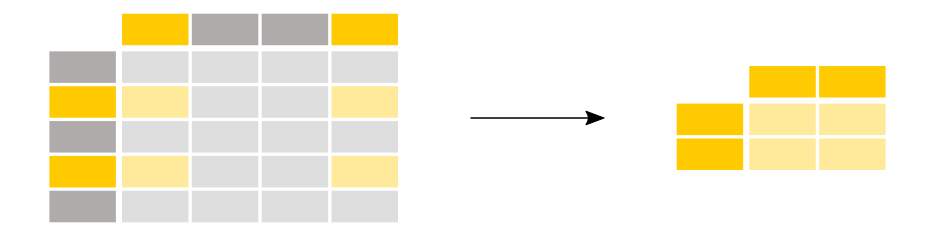

The methods for selecting rows and columns can be combined simulaneously

In [ ]:
# Two columns (survived, passenger class) for passengers > 35 years
titanic.loc[ titanic['Age']>35, ['Survived','Pclass'] ]

## More indexing and selecting

[Pandas Indexing Documentation](https://pandas.pydata.org/docs/user_guide/indexing.html#indexing-basics)


* When selecting subsets of data, square brackets `[]` are used.
* Inside these brackets, you can use a single column/row label, a list of column/row labels, a slice of labels, a conditional expression or a colon.
* Select specific rows and/or columns using `loc` when using the row and column names.
* Select specific rows and/or columns using `iloc` when using the positions in the table.
* You can assign new values to a selection based on `loc`/`iloc`.



## Plotting with pandas

These examples use air quality measurements of NO<sub>2</sub> collected at sites in London, Paris, and Antwerp. 

In [ ]:
import matplotlib.pyplot as plt

# Read the air quality data
aq = pd.read_csv("datasets/air_quality_no2.csv", 
                 index_col='datetime', 
                 parse_dates=['datetime'] )
# Index is from 'datetime', rather than integers 0, 1, 2, etc.

aq.head()

In [ ]:
# Quick plot
# By default, pandas shows one line for each column with numeric data
aq.plot()

In [ ]:
# Plot of just Paris
# We could also subset the DataFrame in any other way introduced above
aq["station_paris"].plot()

In [ ]:
# We could create the same plot with Matplotlib, 
# but that is more verbose
plt.plot( aq.index, 
          aq['station_paris'] )

In [ ]:
# Compare the values measured in London vs. Paris
aq.plot.scatter(x="station_london", 
                y="station_paris", 
                alpha=0.5)

Pandas supports many other plot types using `DataFrame.plot.[PLOTTYPE]()`:
'area',
 'bar',
 'barh',
 'box',
 'density',
 'hexbin',
 'hist',
 'kde',
 'line',
 'pie',
 'scatter'

For an introduction to plots other than the default line plot, see the user guide section about [supported plot styles](https://pandas.pydata.org/docs/user_guide/visualization.html#visualization-other).
 

In many development environments as well as IPython and Jupyter Notebook, use the TAB button to get an overview of the available methods, for example `aq.plot.` + TAB.

In [ ]:
# Press TAB for autocomplete options
aq.plot.

In [ ]:
# Create a boxplot
aq.plot.box()

In [ ]:
# We can combine Matplotlib and Pandas plotting commands

# Create a figure with two panels
fig, axs = plt.subplots( ncols=2, figsize=(10,5) )

# Plot the time series in the left panel
# Use the ax= keyword to specify which axes to plot in
aq.plot(ax=axs[0],
        xlabel='time',
        ylabel='NO2, µg/m3')
# Alternate way to label the x axis
# axs[0].set_xlabel('time')

# Plot scatter plot on right axis
# Use the ax= keyword to specify which axes to plot in
aq.plot.scatter(x='station_london', 
                y='station_paris',
                ax=axs[1],
                alpha=0.5,
                xlabel='Paris NO2, µg/m3',
                ylabel='London NO2, µg/m3')


#### Exercise

1. Create a line plot that shows *only* London and Paris (not Antwerp)
3. Label the y axis with 'NO2, ug/m3'.

Hint: Select the columns that you want before making your plot.

In [ ]:
# Write your code here

## Sort values in a `DataFrame`

Use the `sort_values()` method to sort a `DataFrame` according to values in a single column from smallest to largest. 

In [ ]:
# Sort the Titanic passengers according to their age, smallest to largest
titanic.sort_values('Age')

In [ ]:
# Info for the 5 oldest passengers
titanic.nlargest(5,'Age')

In [ ]:
# The column name is unneccessry for sorting a single column (same with nlargest())
titanic['Age'].sort_values()

## Add columns to a `DataFrame`

Columns can be added to an existing `DataFrame` similarly to adding keys to an dictionary. The new columns can be derived from other columns or not.

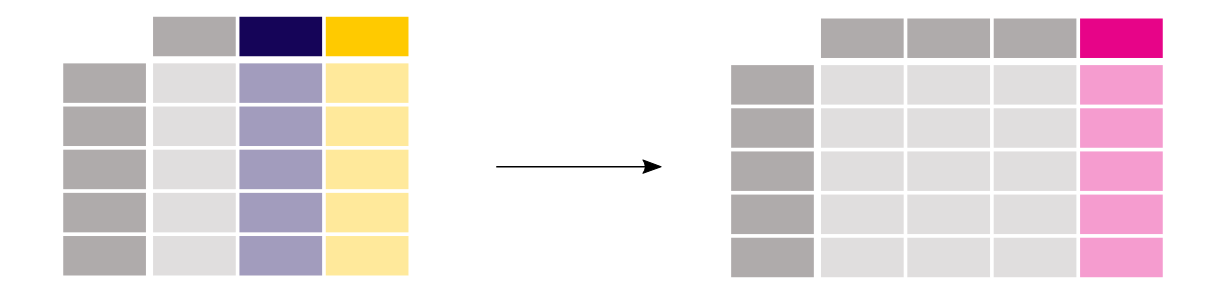

In [ ]:
# Convert NO2 concentration from ug/m3 to ppb;
# 1 ppb = 1.88 ug/m3 at 25 °C, 1 atm)
aq['london_ppb'] = aq['station_london'] / 1.88

Calculations are done ***element-wise***, just like Numpy. (Pandas uses Numpy internally.)

In [ ]:
# Ratio of concentrations in London vs Paris
aq['ratio_london_paris'] = aq['station_london'] / aq['station_paris']
aq.head()

In [ ]:
# A uniform value could also be added
# UK air quality monitoring agency
aq['UK_agency'] = 'DEFRA'
aq.head()

## Reductions

Data reductions in pandas work much like NumPy.

In [ ]:
aq.mean()

In [ ]:
aq.quantile(0.5)

Common `DataFrame` reduction operators
* `mean()`
* `std()`
* `sum()`
* `count()` number of values not missing
* `min()`
* `max()`
* `median()`
* `quantile(q)` find the q-th quantile value (e.g. `quantile(0.5)` is the median)

All of these have an `axis=` keyword.
* `mean(axis=0)` computes mean over rows (default), yielding the mean value for each column
* `mean(axis=1)` computes mean over columns, yielding the mean value for each row

In [ ]:
aq.mean(axis=1)

We can select columns for averaging

In [ ]:
# Two ways to get the same result: mean of the column vs. mean of the DataFrame
print( aq['station_london'].mean(),  # select the station_london column, then take the mean
       aq.mean()['station_london'] ) # compute mean of all columns, then select the station_london value


## Time Indices

Pandas awareness of dates and times is one of its strengths. There are *many* capabilities described in the [time series user guide](https://pandas.pydata.org/docs/user_guide/timeseries.html).

In [ ]:
# Create a DatetimeIndex with daily frequency
time = pd.date_range(start='2015-06-15', 
                     end='2015-07-15', 
                     freq='D')
time

In [ ]:
# DatetimeIndex objects have many useful attributes: year, month, day, hour, minute, second, dayofyear, weekday, date
time.month

In [ ]:
time.dayofyear

In [ ]:
time.weekday

In [ ]:
# Construct a Series with a DatetimeIndex
two_years = pd.date_range(start='2014-01-01', 
                          end='2016-01-01', 
                          freq='D')
timeseries = pd.Series( np.sin( two_years.dayofyear * 2*np.pi / 365),
                       index=two_years)
timeseries.plot()

In [ ]:
# Select a time range using slice notation
timeseries.loc['2015-01-01':'2015-07-01'].plot()

#### Exercise

1. Create a line plot of NO2 air quality that shows *only* May 20 to June 10, 2019.
2. Modify your plot so it only shows London.
3. Label the y axis with 'NO2, ug/m3'.

In [ ]:
# Write your code here

## Construct a datetime from year, month, day, etc.

Some data files contain separate columns for year, month, day, hour, etc. It is helpful to combine them into a datetime object.

In [ ]:
# Sample DataFrame
df = pd.DataFrame(
    {"year": [2015, 2016], 
     "month": [2, 3], 
     "day": [4, 5], 
     "hour": [2, 3],
     "data": [100, 101]}
)

# Construct the datetime and add it as a new column
df['time'] = pd.to_datetime( df[ ['year','month','day','hour'] ] )
# The column names can be omitted if the DataFrame *only* contains time quantities

df

`pd.to_datetime` looks for standard designations of the datetime component in the column names, including:

* required: `year`, `month`, `day`
* optional: `hour`, `minute`, `second`, `millisecond`, `microsecond`, `nanosecond`

## Change the index

For timeseries data, it is useful to use datetime as the index. However any column in a DataFrame can be used as the index.


In [ ]:
# Use the "time" column as the index
df = df.set_index('time')

df

## Rename columns in a `DataFrame`

Both the column and row/index labels can be renamed. Renaming columns is much more common

In [ ]:
# Use a dictionary to rename some columns
aq_renamed = aq.rename( columns={'station_london':'London',
                                 'station_paris':'Paris',
                                 'station_antwerp':'Antwerp'} )
aq_renamed.head()

## Resampling

Since pandas understands time, it can do temporal resampling

In [ ]:
# Read NOAA CRN Millbrook 
filename = 'datasets/NOAA-CRN-Millbrook-2017.txt'
millbrook = pd.read_csv(filename, sep=r'\s+', 
                        na_values=[-9999.0, -99.0], 
                        parse_dates=['LST_DATE'])
# Use the date column as the index
millbrook = millbrook.set_index('LST_DATE')
millbrook.head()

In [ ]:
# Monthly resampler object
millbrook.resample('MS')

In [ ]:
# We need to tell the resampler what statistic to use for each time period (mean, max, min, std, median)

# monthly mean
mon_mean = millbrook.resample('MS').mean(numeric_only=True)
mon_mean.head()

In [ ]:
mon_mean[['T_DAILY_MIN', 'T_DAILY_MEAN', 'T_DAILY_MAX']].plot()

## Rolling

[Rolling](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.rolling.html) applies a function to a "rolling" window moving along the index. We specify the size of the window (weights optional). The `center=` keyword specifies whether the operation is centered over the window midpoint.

In [ ]:
millbrook['T_DAILY_MEAN'].rolling(30, center=True).mean().plot()

## GroupBy

`groupby()` is a powerful DataFrame method in pandas. While it is complicated to understand, it is worth the time investment.

[Pandas GroupBy Documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html)

In [ ]:
# Simple example dataset
experiment = pd.DataFrame(
    {'name':['Alice','Bob','Carol','Dave'],
     'sex':['f','m','f','m'],
     'treatment':['placebo','placebo','drug','drug'],
     'outcome1':[0.5, 0.8, 0.9, 0.8],
     'outcome2':[10, 6, 11, 2]}
)
experiment

In [ ]:
# Compute the means for each treatment group (placebo, drug)
experiment.groupby('treatment').mean(numeric_only=True)

### What happened?

The `groupby` workflow involves 3 steps.

1. **Split**: Partition the data into groups based on some criterion.
2. **Apply**: Do some calculation within each group. The calculations can be 
   - *Aggregation* (most common): e.g. mean, sum, min, max, std, etc.
   - *Transformation*: e.g. normalize or fill NA values within a group
   - *Filtration*: eliminate some groups
4. **Combine**: Put the results back together in a single DataFrame.

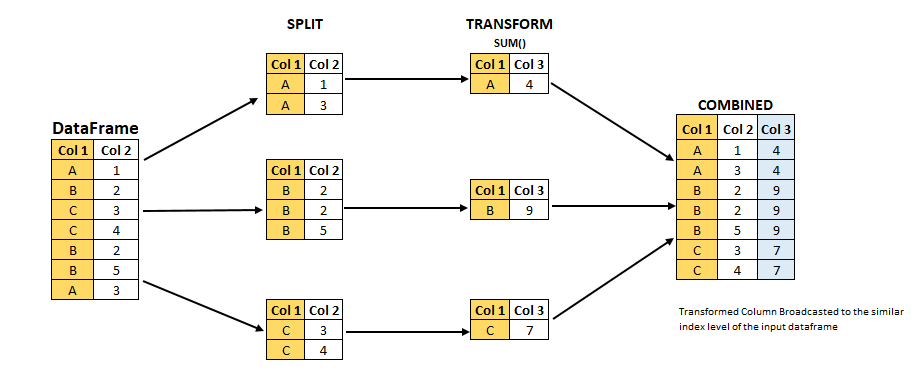

### Time grouping

In [ ]:

millbrook['T_DAILY_MEAN'].groupby(millbrook.index.dayofweek).mean().plot()

### Exercise: Titanic and GroupBy

In an earlier exercise, we computed the survival rates of Titanic passengers with different ticket classes. The process involved selecting a single passenger class, computing the survival, then repeating for other classes. The calculations can be done in a single line with `groupby()`.

Use `groupby()` to group the passengers by their ticket class ('Pclass'), compute the means, and examine the survival fractions.

Extra: Try grouping the passengers by 'Pclass' and 'Sex' simultaneously. 

In [ ]:
# Write your code here
# The DataFrame is named titanic

### Exercise: Earthquakes and GroupBy

The following cell reads a dataset from USGS of global earthquakes in 2024. (magnitude 4 and larger) Use the `groupby()` function to answer the following questions:

* Which country had the largest number of earthquakes?
* What was the largest magnitude earthquake in each country?

Focus on the columns named `'mag'` (magnitude) and `'country'`.

<details>
Data for other time periods can be aquired by modifying this link. http://earthquake.usgs.gov/fdsnws/event/1/query.csv?starttime=2024-01-01%2000:00:00&endtime=2024-12-31%2023:59:59&minmagnitude=4&orderby=time
</details>

In [ ]:
# Read the earthquake data
quakes = pd.read_csv('datasets/usgs_earthquakes_2024.csv.gz')

# Inspect the 'place' column
quakes['place']

# The country (or state) follows the comma in the 'place' column
#quakes['country'] = quakes['place'].str.split(', ').str[-1]

# quakes.info()

# Write your code here

### Exercise: Mean annual cycle and anomalies

El Niño, La Niña, and the Southern Oscillation (ENSO) is a semi-periodic variation in the sea surface temperature (SST) of the equatorial Pacific Ocean. ENSO is the largest mode of variability in Earth's weather (except the annual cycle) and it affects weather throughout the world through teleconnections. 

ENSO is commonly tracked by the mean SST in several regions shown in the figure below.
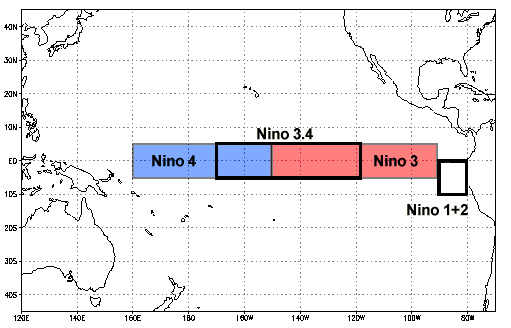

More specifically, the SST ***anomaly*** is used to identify El Niño and La Niña: **Anomaly** = **[Actual temperature]** - **[Mean temperature for the calendar month]**. El Ninõ is usually identified when temperature anomalies are ≥ 0.5 °C. La Niña is when temperature anomalies are ≤ –0.5 °C.

Use the dataset below to compute and plot NINO3.4 temperature anomalies. 


In [ ]:
# Read SST data
sst = pd.read_csv( 'datasets/enso_sst.csv', 
                  comment='#', 
                  index_col='date' )

sst

# Write your code here

### Review Exercise

Do the following with NOAA CRN data from Millbrook, NY. 

1. Find the conditions on Aug 7, 2017. The mean temperature was 15.8 °C. What was the mean RH? Did it precipitate?
2. Make a boxplot that looks like the following 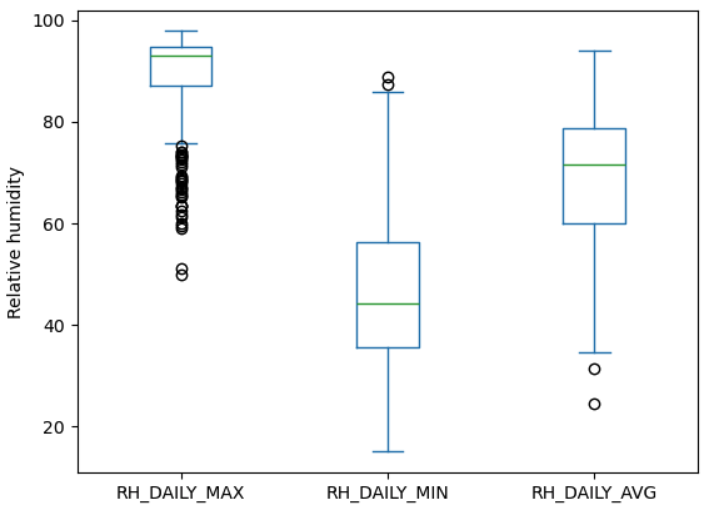
3. Make a scatter plot of precipitation ('P_DAILY_CALC') vs solar radiation ('SOLARAD_DAILY'). Why is there an association between these two variables?
4. Plot or print monthly mean relative humidity ('RH_DAILY_AVG'). Which month had the highest relative humidity in 2017?

In [ ]:
# Re-read NOAA CRN Millbrook 
filename = 'datasets/NOAA-CRN-Millbrook-2017.txt'
millbrook = pd.read_csv(filename, sep=r'\s+', 
                        na_values=[-9999.0, -99.0], 
                        parse_dates=['LST_DATE'])
# Use the date column as the index
millbrook = millbrook.set_index('LST_DATE')

# Write your code here

## Review Questions

### Code snippet

A pandas `DataFrame` named `weather` has the following contents.

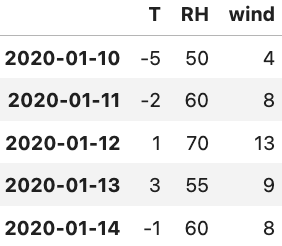

Write pandas commands to access each of these parts of `weather`.

1. `T`
2. `T` and `wind` together
3. All variables for 2020-01-11
4. All variables for 2020-01-11 through 2020-01-13
5. RH for 2020-01-12
6. All variables where T < 0

In [ ]:
# Test your answers
weather = pd.DataFrame( 
        {'T':[-5, -2, 1, 3, -1],
        'RH':[50,60,70,55,60],
        'wind': [4,8,13,9,8]},
        index=pd.date_range('2020-01-10','2020-01-14', freq='D'))
weather

### Read code

A pandas `DataFrame` named `weather` has the following contents.

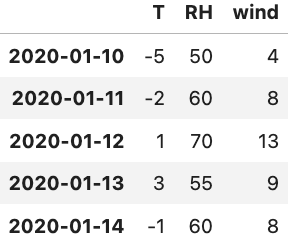

What output will the following produce or will an error occur?

1. `weather.iloc[1]`
2. `weather.loc[1]`
3. `weather.iloc[1,2]`
4. `weather.iloc[5]`
5. `weather.loc['RH']`
6. `weather.loc[:,'RH']`
7. `weather['T'].iloc[0]`
8. `weather.iloc[0]['T']`